In [1]:
import pandas as pd
import duckdb
con = duckdb.connect()



In [2]:
# load the small CSVs

patients = pd.read_csv("/home/ubuntu/condition-aware_risk_CDSS/data/csv/patients.csv")
admissions = pd.read_csv("/home/ubuntu/condition-aware_risk_CDSS/data/csv/admissions.csv")
icustays = pd.read_csv("/home/ubuntu/condition-aware_risk_CDSS/data/csv/icustays.csv")

In [3]:
# merge patients and admissions on subject_id
patients_admissions = pd.merge(patients, admissions, on="subject_id", how="left")
# merge the result with icustays on hadm_id
patients_admissions_icustays = pd.merge(patients_admissions,
                                         icustays, on="hadm_id", how="left")

base_df = patients_admissions_icustays

print(base_df.shape)
print(base_df.head())

(696419, 28)
   subject_id_x gender  anchor_age  anchor_year anchor_year_group         dod  \
0      10000032      F          52         2180       2014 - 2016  2180-09-09   
1      10000032      F          52         2180       2014 - 2016  2180-09-09   
2      10000032      F          52         2180       2014 - 2016  2180-09-09   
3      10000032      F          52         2180       2014 - 2016  2180-09-09   
4      10000048      F          23         2126       2008 - 2010         NaN   

      hadm_id            admittime            dischtime deathtime  ...  \
0  22595853.0  2180-05-06 22:23:00  2180-05-07 17:15:00       NaN  ...   
1  22841357.0  2180-06-26 18:27:00  2180-06-27 18:49:00       NaN  ...   
2  25742920.0  2180-08-05 23:44:00  2180-08-07 17:50:00       NaN  ...   
3  29079034.0  2180-07-23 12:35:00  2180-07-25 17:55:00       NaN  ...   
4         NaN                  NaN                  NaN       NaN  ...   

             edregtime            edouttime hospital_ex

In [4]:
# load the diagnoses_icd.csv file
diagnoses_icd = pd.read_csv("/home/ubuntu/condition-aware_risk_CDSS/data/csv/diagnoses_icd.csv")
print(f"diagnoses_icd.shape: {diagnoses_icd.shape}")

# filter diagnoses_icd to only include rows where hadm_id is in base_df
diagnoses = diagnoses_icd[diagnoses_icd["hadm_id"].isin(base_df["hadm_id"])]
print(f"diagnoses.shape: {diagnoses.shape}") 

#ensure columns are clean
diagnoses.columns = diagnoses.columns.str.strip()

# one hot encode the ICD9 codes in diagnoses
diagnoses['diag_flag'] = 1

diag_sparse = pd.get_dummies(diagnoses, 
                            columns=['icd_code'], 
                            prefix='ICD',
                            sparse=True)
print(f"diag_sparse.shape: {diag_sparse.shape}")

# merge diag_sparse with base_df on hadm_id
diag_sparse = diag_sparse.groupby('hadm_id').sum()
print(diag_sparse.shape)

diagnoses_icd.shape: (6364488, 5)
diagnoses.shape: (6364488, 5)
diag_sparse.shape: (6364488, 28567)


KeyboardInterrupt: 

In [2]:
from pathlib import Path

RAW_DIR = "/home/ubuntu/condition-aware_risk_CDSS/data/raw"
processed_dir = Path("/home/ubuntu/condition-aware_risk_CDSS/data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

cohort_query = f"""
WITH dx AS (
    SELECT
        subject_id,
        hadm_id,
        icd_code,
        icd_version,
        CASE
            WHEN (icd_version = 9 AND icd_code LIKE '250%')
              OR (icd_version = 10 AND (icd_code LIKE 'E08%' OR icd_code LIKE 'E09%' OR icd_code LIKE 'E10%' OR icd_code LIKE 'E11%' OR icd_code LIKE 'E13%'))
                THEN 'diabetes'
            WHEN (icd_version = 9 AND icd_code LIKE '585%')
              OR (icd_version = 10 AND icd_code LIKE 'N18%')
                THEN 'ckd'
            WHEN (icd_version = 9 AND icd_code LIKE '428%')
              OR (icd_version = 10 AND icd_code LIKE 'I50%')
                THEN 'heart_failure'
            WHEN (icd_version = 9 AND (icd_code LIKE '038%' OR icd_code LIKE '99591%' OR icd_code LIKE '99592%' OR icd_code LIKE '78552%'))
              OR (icd_version = 10 AND (icd_code LIKE 'A40%' OR icd_code LIKE 'A41%' OR icd_code LIKE 'R652%'))
                THEN 'sepsis'
            ELSE NULL
        END AS condition_label
    FROM read_csv_auto('{RAW_DIR}/diagnoses_icd.csv', header = true)
),
dx_filtered AS (
    SELECT DISTINCT subject_id, hadm_id, condition_label
    FROM dx
    WHERE condition_label IS NOT NULL
),
icu_base AS (
    SELECT
        i.subject_id,
        i.hadm_id,
        i.stay_id,
        i.intime,
        i.outtime,
        a.admission_type,
        a.hospital_expire_flag,
        p.gender,
        p.anchor_age,
        p.anchor_year_group
    FROM read_csv_auto('{RAW_DIR}/icustays.csv', header = true) i
    LEFT JOIN read_csv_auto('{RAW_DIR}/admissions.csv', header = true) a
      ON i.hadm_id = a.hadm_id
    LEFT JOIN read_csv_auto('{RAW_DIR}/patients.csv', header = true) p
      ON i.subject_id = p.subject_id
)
SELECT
    b.subject_id,
    b.hadm_id,
    b.stay_id,
    b.intime,
    b.outtime,
    b.admission_type,
    b.hospital_expire_flag,
    b.gender,
    b.anchor_age,
    b.anchor_year_group,
    d.condition_label
FROM icu_base b
INNER JOIN dx_filtered d
  ON b.subject_id = d.subject_id
 AND b.hadm_id = d.hadm_id
ORDER BY b.subject_id, b.hadm_id, b.stay_id;
"""

condition_cohort = con.execute(cohort_query).df()

print("condition_cohort shape:", condition_cohort.shape)
print("\nCondition counts:")
print(condition_cohort['condition_label'].value_counts(dropna=False))
print("\nPreview:")
print(condition_cohort.head())

out_file = processed_dir / "condition_cohort_table.csv"
condition_cohort.to_csv(out_file, index=False)
print(f"\nSaved: {out_file}")

condition_cohort shape: (92938, 11)

Condition counts:
condition_label
diabetes         29105
heart_failure    26034
ckd              20647
sepsis           17152
Name: count, dtype: int64

Preview:
   subject_id   hadm_id   stay_id              intime             outtime  \
0    10000690  25860671  37081114 2150-11-02 19:37:00 2150-11-06 17:03:17   
1    10000980  26913865  39765666 2189-06-27 08:42:00 2189-06-27 20:38:27   
2    10000980  26913865  39765666 2189-06-27 08:42:00 2189-06-27 20:38:27   
3    10000980  26913865  39765666 2189-06-27 08:42:00 2189-06-27 20:38:27   
4    10001843  26133978  39698942 2134-12-05 18:50:03 2134-12-06 14:38:26   

  admission_type  hospital_expire_flag gender  anchor_age anchor_year_group  \
0       EW EMER.                     0      F          86       2008 - 2010   
1       EW EMER.                     0      F          73       2008 - 2010   
2       EW EMER.                     0      F          73       2008 - 2010   
3       EW EMER.      

In [3]:
# one row per ICU stay + multi-condition flags
stay_base_cols = [
    'subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime',
    'admission_type', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year_group'
]

stay_base = condition_cohort[stay_base_cols].drop_duplicates(subset=['stay_id']).copy()

condition_flags = (
    pd.crosstab(condition_cohort['stay_id'], condition_cohort['condition_label'])
    .rename(columns={
        'diabetes': 'has_diabetes',
        'ckd': 'has_ckd',
        'heart_failure': 'has_heart_failure',
        'sepsis': 'has_sepsis'
    })
    .reset_index()
)

for col in ['has_diabetes', 'has_ckd', 'has_heart_failure', 'has_sepsis']:
    if col not in condition_flags.columns:
        condition_flags[col] = 0

condition_model_table = stay_base.merge(condition_flags, on='stay_id', how='left').fillna(0)

# keep binary flags as int
for col in ['has_diabetes', 'has_ckd', 'has_heart_failure', 'has_sepsis']:
    condition_model_table[col] = condition_model_table[col].astype(int)

print('condition_model_table shape:', condition_model_table.shape)
print(condition_model_table.head())

model_out_file = processed_dir / 'condition_model_table_v1.csv'
condition_model_table.to_csv(model_out_file, index=False)
print(f"Saved: {model_out_file}")

condition_model_table shape: (55203, 14)
   subject_id   hadm_id   stay_id              intime              outtime  \
0    10000690  25860671  37081114 2150-11-02 19:37:00  2150-11-06 17:03:17   
1    10000980  26913865  39765666 2189-06-27 08:42:00  2189-06-27 20:38:27   
2    10001843  26133978  39698942 2134-12-05 18:50:03  2134-12-06 14:38:26   
3    10002013  23581541  39060235 2160-05-18 10:00:53  2160-05-19 17:33:33   
4    10002155  20345487  32358465 2131-03-09 21:33:00  2131-03-10 18:09:21   

                admission_type  hospital_expire_flag gender  anchor_age  \
0                     EW EMER.                     0      F          86   
1                     EW EMER.                     0      F          73   
2                       URGENT                     1      M          73   
3  SURGICAL SAME DAY ADMISSION                     0      F          53   
4                     EW EMER.                     1      F          80   

  anchor_year_group  has_ckd  has_diabe

In [8]:
# 24h vitals from chartevents using DuckDB (no full pandas load of chart events)

# prepare stay_id + ICU intime table for join filtering
stay_time_df = condition_model_table[['stay_id', 'intime']].copy()
stay_time_df['stay_id'] = pd.to_numeric(stay_time_df['stay_id'], errors='coerce').astype('Int64')
stay_time_df['intime'] = pd.to_datetime(stay_time_df['intime'], errors='coerce')
stay_time_df = stay_time_df.dropna(subset=['stay_id', 'intime']).drop_duplicates(subset=['stay_id'])

con.register('stay_time_df', stay_time_df)

# vital itemids (MIMIC-IV common IDs)
# HR:220045, SBP:220179, DBP:220180, MAP:220181, RR:220210, SpO2:220277, Temp(F):223761
vitals_24h_query = f"""
WITH stays AS (
    SELECT CAST(stay_id AS BIGINT) AS stay_id, CAST(intime AS TIMESTAMP) AS intime
    FROM stay_time_df
),
ce AS (
    SELECT
        CAST(stay_id AS BIGINT) AS stay_id,
        CAST(charttime AS TIMESTAMP) AS charttime,
        itemid,
        valuenum
    FROM read_csv_auto('{RAW_DIR}/chartevents.csv.gz', header = true)
    WHERE itemid IN (220045, 220179, 220180, 220181, 220210, 220277, 223761)
      AND valuenum IS NOT NULL
),
ce_24h AS (
    SELECT
        c.stay_id,
        c.charttime,
        c.itemid,
        c.valuenum,
        CASE
            WHEN c.itemid = 220045 THEN 'heart_rate'
            WHEN c.itemid = 220179 THEN 'sbp'
            WHEN c.itemid = 220180 THEN 'dbp'
            WHEN c.itemid = 220181 THEN 'map'
            WHEN c.itemid = 220210 THEN 'resp_rate'
            WHEN c.itemid = 220277 THEN 'spo2'
            WHEN c.itemid = 223761 THEN 'temp_f'
        END AS vital_name
    FROM ce c
    INNER JOIN stays s
        ON c.stay_id = s.stay_id
    WHERE c.charttime >= s.intime
      AND c.charttime < s.intime + INTERVAL 24 HOUR
),
vital_agg AS (
    SELECT
        stay_id,
        vital_name,
        COUNT(*) AS n,
        AVG(valuenum) AS mean,
        MIN(valuenum) AS min,
        MAX(valuenum) AS max,
        STDDEV_SAMP(valuenum) AS std
    FROM ce_24h
    GROUP BY stay_id, vital_name
)
SELECT *
FROM vital_agg
ORDER BY stay_id, vital_name;
"""

vitals_24h_long = con.execute(vitals_24h_query).df()

print('vitals_24h_long shape:', vitals_24h_long.shape)
print(vitals_24h_long.head())

# pivot to one-row-per-stay feature table
vitals_24h_wide = vitals_24h_long.pivot_table(
    index='stay_id',
    columns='vital_name',
    values=['n', 'mean', 'min', 'max', 'std'],
    aggfunc='first'
)

vitals_24h_wide.columns = [f"{vital}_{stat}" for stat, vital in vitals_24h_wide.columns]
vitals_24h_wide = vitals_24h_wide.reset_index()

# merge to modeling table
condition_model_with_vitals = condition_model_table.merge(vitals_24h_wide, on='stay_id', how='left')

print('condition_model_with_vitals shape:', condition_model_with_vitals.shape)
print(condition_model_with_vitals.head())

vitals_long_out = processed_dir / 'vitals_24h_long.csv'
vitals_wide_out = processed_dir / 'vitals_24h_features.csv'
model_v2_out = processed_dir / 'condition_model_table_v2_with_24h_vitals.csv'

vitals_24h_long.to_csv(vitals_long_out, index=False)
vitals_24h_wide.to_csv(vitals_wide_out, index=False)
condition_model_with_vitals.to_csv(model_v2_out, index=False)

print(f"Saved: {vitals_long_out}")
print(f"Saved: {vitals_wide_out}")
print(f"Saved: {model_v2_out}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

vitals_24h_long shape: (367546, 7)
    stay_id  vital_name   n    mean    min    max        std
0  30000213         dbp  25   56.16   47.0   69.0   5.398148
1  30000213  heart_rate  25   81.68   66.0   91.0   6.974477
2  30000213         map  25   79.12   69.0   95.0   7.001905
3  30000213   resp_rate  25   19.08   14.0   26.0   3.303029
4  30000213         sbp  25  134.92  116.0  168.0  13.810986
condition_model_with_vitals shape: (55203, 49)
   subject_id   hadm_id   stay_id              intime              outtime  \
0    10000690  25860671  37081114 2150-11-02 19:37:00  2150-11-06 17:03:17   
1    10000980  26913865  39765666 2189-06-27 08:42:00  2189-06-27 20:38:27   
2    10001843  26133978  39698942 2134-12-05 18:50:03  2134-12-06 14:38:26   
3    10002013  23581541  39060235 2160-05-18 10:00:53  2160-05-19 17:33:33   
4    10002155  20345487  32358465 2131-03-09 21:33:00  2131-03-10 18:09:21   

                admission_type  hospital_expire_flag gender  anchor_age  \
0       

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

trend_df shape: (288, 5)
   hospital_expire_flag  hour_from_icu  vital_name  mean_value  n_obs
0                     0              0  heart_rate   90.631272  36211
1                     0              1  heart_rate   88.443733  60654
2                     0              2  heart_rate   86.817318  58008
3                     0              3  heart_rate   85.938938  58190
4                     0              4  heart_rate   85.515501  57804


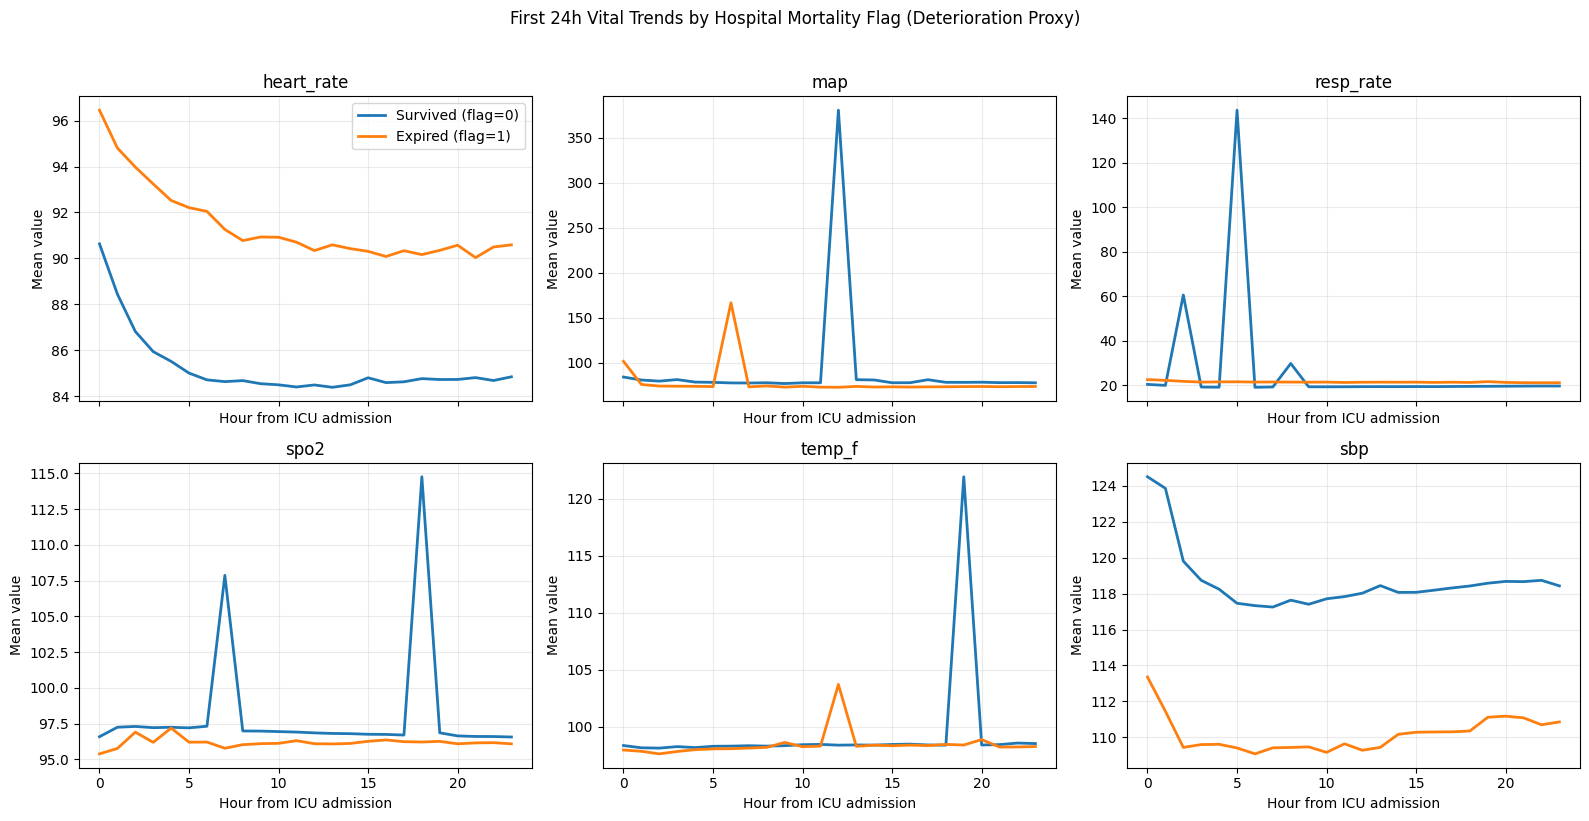

In [4]:
# Trend plot: hourly first-24h vitals, split by mortality flag (proxy for deterioration)
import matplotlib.pyplot as plt

# prepare stay-level table for trend extraction
stay_trend_df = condition_model_table[['stay_id', 'intime', 'hospital_expire_flag']].copy()
stay_trend_df['stay_id'] = pd.to_numeric(stay_trend_df['stay_id'], errors='coerce').astype('Int64')
stay_trend_df['intime'] = pd.to_datetime(stay_trend_df['intime'], errors='coerce')
stay_trend_df['hospital_expire_flag'] = pd.to_numeric(
    stay_trend_df['hospital_expire_flag'], errors='coerce'
).fillna(0).astype(int)
stay_trend_df = stay_trend_df.dropna(subset=['stay_id', 'intime']).drop_duplicates(subset=['stay_id'])

con.register('stay_trend_df', stay_trend_df)

trend_query = f"""
WITH stays AS (
    SELECT
        CAST(stay_id AS BIGINT) AS stay_id,
        CAST(intime AS TIMESTAMP) AS intime,
        CAST(hospital_expire_flag AS INTEGER) AS hospital_expire_flag
    FROM stay_trend_df
),
ce AS (
    SELECT
        CAST(stay_id AS BIGINT) AS stay_id,
        CAST(charttime AS TIMESTAMP) AS charttime,
        itemid,
        valuenum
    FROM read_csv_auto('{RAW_DIR}/chartevents.csv.gz', header=true)
    WHERE itemid IN (220045, 220179, 220181, 220210, 220277, 223761)
      AND valuenum IS NOT NULL
),
ce_24h AS (
    SELECT
        c.stay_id,
        s.hospital_expire_flag,
        date_diff('hour', s.intime, c.charttime) AS hour_from_icu,
        CASE
            WHEN c.itemid = 220045 THEN 'heart_rate'
            WHEN c.itemid = 220179 THEN 'sbp'
            WHEN c.itemid = 220181 THEN 'map'
            WHEN c.itemid = 220210 THEN 'resp_rate'
            WHEN c.itemid = 220277 THEN 'spo2'
            WHEN c.itemid = 223761 THEN 'temp_f'
        END AS vital_name,
        c.valuenum
    FROM ce c
    INNER JOIN stays s ON c.stay_id = s.stay_id
    WHERE c.charttime >= s.intime
      AND c.charttime < s.intime + INTERVAL 24 HOUR
),
hourly AS (
    SELECT
        hospital_expire_flag,
        hour_from_icu,
        vital_name,
        AVG(valuenum) AS mean_value,
        COUNT(*) AS n_obs
    FROM ce_24h
    WHERE hour_from_icu BETWEEN 0 AND 23
    GROUP BY hospital_expire_flag, hour_from_icu, vital_name
)
SELECT *
FROM hourly
ORDER BY vital_name, hospital_expire_flag, hour_from_icu;
"""

trend_df = con.execute(trend_query).df()

print('trend_df shape:', trend_df.shape)
print(trend_df.head())

vitals_to_plot = ['heart_rate', 'map', 'resp_rate', 'spo2', 'temp_f', 'sbp']
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for idx, vital in enumerate(vitals_to_plot):
    ax = axes[idx]
    subset = trend_df[trend_df['vital_name'] == vital]

    alive = subset[subset['hospital_expire_flag'] == 0]
    expired = subset[subset['hospital_expire_flag'] == 1]

    ax.plot(alive['hour_from_icu'], alive['mean_value'], label='Survived (flag=0)', linewidth=2)
    ax.plot(expired['hour_from_icu'], expired['mean_value'], label='Expired (flag=1)', linewidth=2)
    ax.set_title(vital)
    ax.set_xlabel('Hour from ICU admission')
    ax.set_ylabel('Mean value')
    ax.grid(alpha=0.25)

axes[0].legend(loc='best')
plt.suptitle('First 24h Vital Trends by Hospital Mortality Flag (Deterioration Proxy)', y=1.02)
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

trend_clean_df shape: (288, 7)
   hospital_expire_flag  hour_from_icu  vital_name  n_obs   p25  median    p75
0                     0              0  heart_rate  36198  75.0    88.0  104.0
1                     0              1  heart_rate  60642  73.0    86.0  101.0
2                     0              2  heart_rate  58002  72.0    84.0   99.0
3                     0              3  heart_rate  58181  72.0    84.0   97.0
4                     0              4  heart_rate  57795  72.0    83.0   96.0


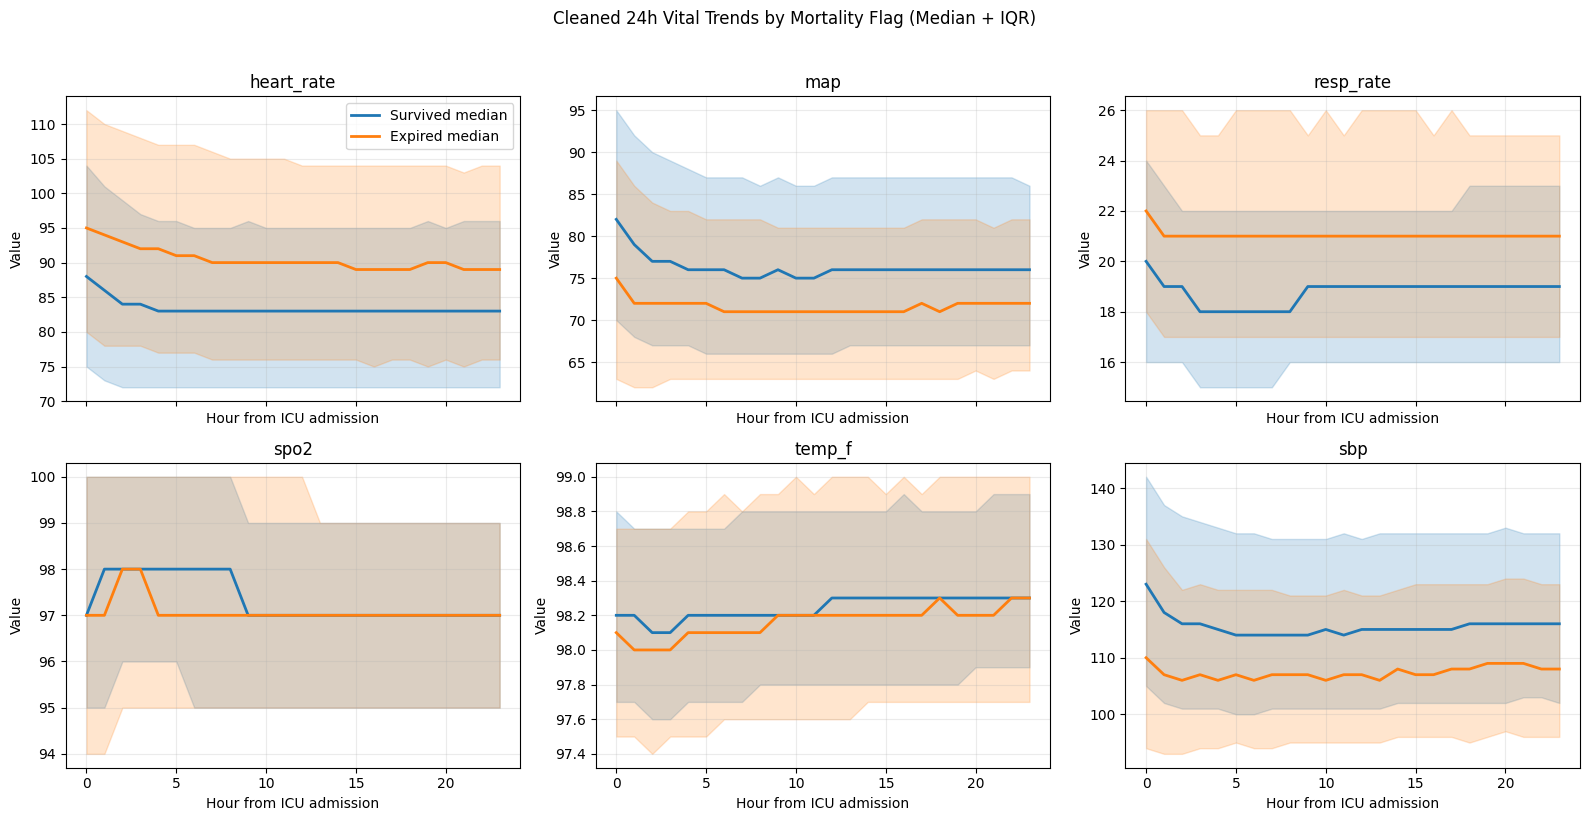

Saved: /home/ubuntu/condition-aware_risk_CDSS/data/processed/vitals_24h_hourly_median_iqr_by_mortality.csv


In [5]:
# Cell 9: cleaned deterioration trend (physiologic filters + median/IQR)

# reuse cohort stays with intime + mortality flag
stay_trend_df = condition_model_table[['stay_id', 'intime', 'hospital_expire_flag']].copy()
stay_trend_df['stay_id'] = pd.to_numeric(stay_trend_df['stay_id'], errors='coerce').astype('Int64')
stay_trend_df['intime'] = pd.to_datetime(stay_trend_df['intime'], errors='coerce')
stay_trend_df['hospital_expire_flag'] = pd.to_numeric(
    stay_trend_df['hospital_expire_flag'], errors='coerce'
).fillna(0).astype(int)
stay_trend_df = stay_trend_df.dropna(subset=['stay_id', 'intime']).drop_duplicates(subset=['stay_id'])

con.register('stay_trend_df', stay_trend_df)

# robust summary using physiologic range filters and median/IQR
trend_clean_query = f"""
WITH stays AS (
    SELECT
        CAST(stay_id AS BIGINT) AS stay_id,
        CAST(intime AS TIMESTAMP) AS intime,
        CAST(hospital_expire_flag AS INTEGER) AS hospital_expire_flag
    FROM stay_trend_df
),
ce AS (
    SELECT
        CAST(stay_id AS BIGINT) AS stay_id,
        CAST(charttime AS TIMESTAMP) AS charttime,
        itemid,
        valuenum
    FROM read_csv_auto('{RAW_DIR}/chartevents.csv.gz', header=true)
    WHERE itemid IN (220045, 220179, 220181, 220210, 220277, 223761)
      AND valuenum IS NOT NULL
),
ce_24h AS (
    SELECT
        c.stay_id,
        s.hospital_expire_flag,
        date_diff('hour', s.intime, c.charttime) AS hour_from_icu,
        CASE
            WHEN c.itemid = 220045 THEN 'heart_rate'
            WHEN c.itemid = 220179 THEN 'sbp'
            WHEN c.itemid = 220181 THEN 'map'
            WHEN c.itemid = 220210 THEN 'resp_rate'
            WHEN c.itemid = 220277 THEN 'spo2'
            WHEN c.itemid = 223761 THEN 'temp_f'
        END AS vital_name,
        c.valuenum
    FROM ce c
    INNER JOIN stays s ON c.stay_id = s.stay_id
    WHERE c.charttime >= s.intime
      AND c.charttime < s.intime + INTERVAL 24 HOUR
      AND date_diff('hour', s.intime, c.charttime) BETWEEN 0 AND 23
),
ce_clean AS (
    SELECT *
    FROM ce_24h
    WHERE (
        (vital_name = 'heart_rate' AND valuenum BETWEEN 20 AND 250) OR
        (vital_name = 'sbp'        AND valuenum BETWEEN 40 AND 260) OR
        (vital_name = 'map'        AND valuenum BETWEEN 20 AND 180) OR
        (vital_name = 'resp_rate'  AND valuenum BETWEEN 4  AND 80)  OR
        (vital_name = 'spo2'       AND valuenum BETWEEN 50 AND 100) OR
        (vital_name = 'temp_f'     AND valuenum BETWEEN 86 AND 110)
    )
),
hourly AS (
    SELECT
        hospital_expire_flag,
        hour_from_icu,
        vital_name,
        COUNT(*) AS n_obs,
        quantile_cont(valuenum, 0.25) AS p25,
        quantile_cont(valuenum, 0.50) AS median,
        quantile_cont(valuenum, 0.75) AS p75
    FROM ce_clean
    GROUP BY hospital_expire_flag, hour_from_icu, vital_name
)
SELECT *
FROM hourly
ORDER BY vital_name, hospital_expire_flag, hour_from_icu;
"""

trend_clean_df = con.execute(trend_clean_query).df()
print('trend_clean_df shape:', trend_clean_df.shape)
print(trend_clean_df.head())

vitals_to_plot = ['heart_rate', 'map', 'resp_rate', 'spo2', 'temp_f', 'sbp']
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for idx, vital in enumerate(vitals_to_plot):
    ax = axes[idx]
    subset = trend_clean_df[trend_clean_df['vital_name'] == vital]

    alive = subset[subset['hospital_expire_flag'] == 0].sort_values('hour_from_icu')
    expired = subset[subset['hospital_expire_flag'] == 1].sort_values('hour_from_icu')

    ax.plot(alive['hour_from_icu'], alive['median'], label='Survived median', linewidth=2, color='tab:blue')
    ax.fill_between(alive['hour_from_icu'], alive['p25'], alive['p75'], color='tab:blue', alpha=0.20)

    ax.plot(expired['hour_from_icu'], expired['median'], label='Expired median', linewidth=2, color='tab:orange')
    ax.fill_between(expired['hour_from_icu'], expired['p25'], expired['p75'], color='tab:orange', alpha=0.20)

    ax.set_title(vital)
    ax.set_xlabel('Hour from ICU admission')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.25)

axes[0].legend(loc='best')
plt.suptitle('Cleaned 24h Vital Trends by Mortality Flag (Median + IQR)', y=1.02)
plt.tight_layout()
plt.show()

# save trend summary for reuse
trend_clean_out = processed_dir / 'vitals_24h_hourly_median_iqr_by_mortality.csv'
trend_clean_df.to_csv(trend_clean_out, index=False)
print(f"Saved: {trend_clean_out}")

Vital separation summary (expired - survived):
   vital_name  mean_delta  mean_abs_delta  max_abs_delta
3         sbp   -8.166667        8.166667           13.0
0  heart_rate    7.041667        7.041667            9.0
1         map   -4.666667        4.666667            7.0
2   resp_rate    2.250000        2.250000            3.0
4        spo2   -0.250000        0.250000            1.0
5      temp_f   -0.079167        0.079167            0.2


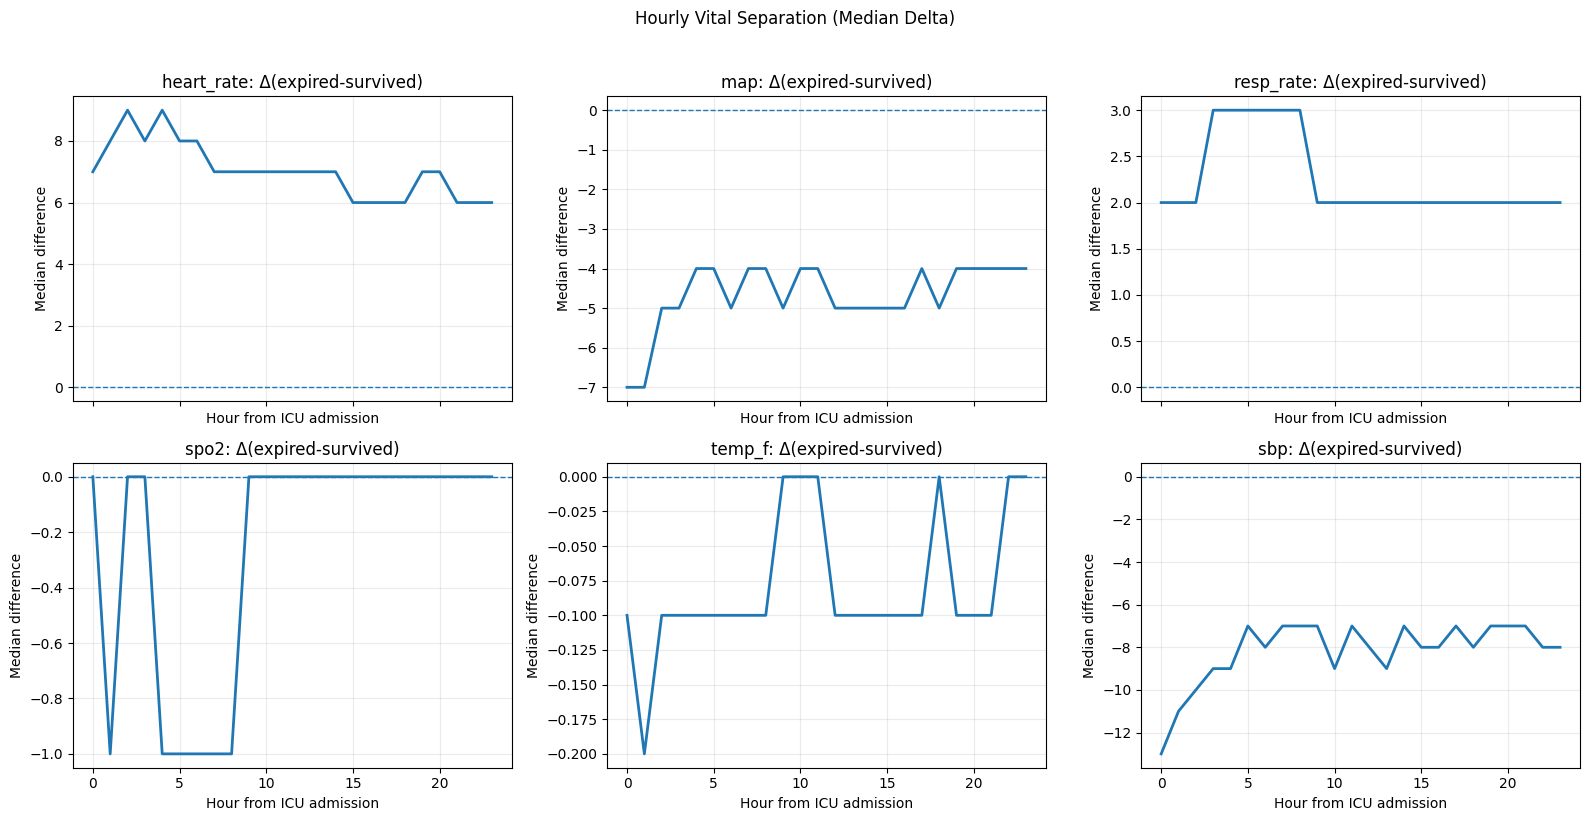

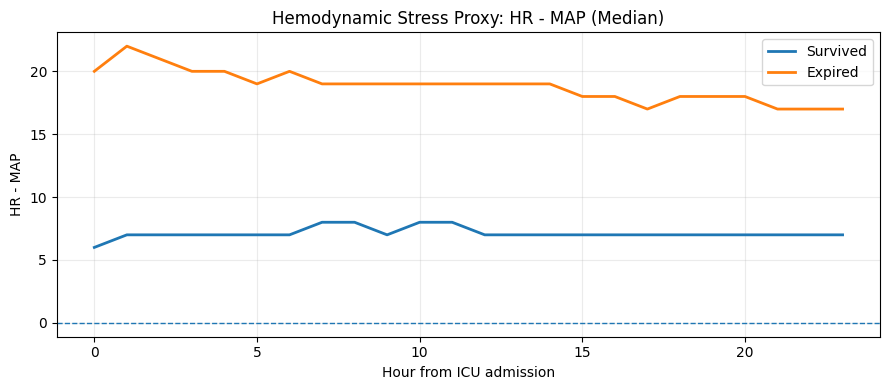

Saved: /home/ubuntu/condition-aware_risk_CDSS/data/processed/vitals_hourly_median_delta_summary.csv
Saved: /home/ubuntu/condition-aware_risk_CDSS/data/processed/vitals_hourly_median_delta_timeseries.csv
Saved: /home/ubuntu/condition-aware_risk_CDSS/data/processed/hemodynamic_stress_hr_minus_map.csv


In [6]:
# Cell 10: quantify separation + hemodynamic stress trend
import numpy as np

# 1) Compute hourly median deltas (expired - survived)
median_pivot = (
    trend_clean_df
    .pivot_table(
        index=['hour_from_icu', 'vital_name'],
        columns='hospital_expire_flag',
        values='median',
        aggfunc='first'
    )
    .rename(columns={0: 'median_survived', 1: 'median_expired'})
    .reset_index()
)

median_pivot = median_pivot.dropna(subset=['median_survived', 'median_expired'])
median_pivot['delta_exp_minus_surv'] = median_pivot['median_expired'] - median_pivot['median_survived']
median_pivot['abs_delta'] = median_pivot['delta_exp_minus_surv'].abs()

# 2) Rank vitals by separation strength
vital_separation_summary = (
    median_pivot
    .groupby('vital_name', as_index=False)
    .agg(
        mean_delta=('delta_exp_minus_surv', 'mean'),
        mean_abs_delta=('abs_delta', 'mean'),
        max_abs_delta=('abs_delta', 'max')
    )
    .sort_values('mean_abs_delta', ascending=False)
)

print('Vital separation summary (expired - survived):')
print(vital_separation_summary)

# 3) Plot hourly delta curves per vital
vitals_to_plot = ['heart_rate', 'map', 'resp_rate', 'spo2', 'temp_f', 'sbp']
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for idx, vital in enumerate(vitals_to_plot):
    ax = axes[idx]
    v = median_pivot[median_pivot['vital_name'] == vital].sort_values('hour_from_icu')
    ax.plot(v['hour_from_icu'], v['delta_exp_minus_surv'], linewidth=2)
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(f"{vital}: Δ(expired-survived)")
    ax.set_xlabel('Hour from ICU admission')
    ax.set_ylabel('Median difference')
    ax.grid(alpha=0.25)

plt.suptitle('Hourly Vital Separation (Median Delta)', y=1.02)
plt.tight_layout()
plt.show()

# 4) Hemodynamic stress index: HR - MAP (group medians)
hr = trend_clean_df[trend_clean_df['vital_name'] == 'heart_rate'][
    ['hospital_expire_flag', 'hour_from_icu', 'median']
].rename(columns={'median': 'hr_median'})

map_df = trend_clean_df[trend_clean_df['vital_name'] == 'map'][
    ['hospital_expire_flag', 'hour_from_icu', 'median']
].rename(columns={'median': 'map_median'})

hemo = hr.merge(map_df, on=['hospital_expire_flag', 'hour_from_icu'], how='inner')
hemo['hr_minus_map'] = hemo['hr_median'] - hemo['map_median']

fig, ax = plt.subplots(figsize=(9, 4))
for flag, label, color in [(0, 'Survived', 'tab:blue'), (1, 'Expired', 'tab:orange')]:
    h = hemo[hemo['hospital_expire_flag'] == flag].sort_values('hour_from_icu')
    ax.plot(h['hour_from_icu'], h['hr_minus_map'], label=label, color=color, linewidth=2)

ax.set_title('Hemodynamic Stress Proxy: HR - MAP (Median)')
ax.set_xlabel('Hour from ICU admission')
ax.set_ylabel('HR - MAP')
ax.axhline(0, linestyle='--', linewidth=1)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 5) Save outputs
sep_out = processed_dir / 'vitals_hourly_median_delta_summary.csv'
sep_hourly_out = processed_dir / 'vitals_hourly_median_delta_timeseries.csv'
hemo_out = processed_dir / 'hemodynamic_stress_hr_minus_map.csv'

vital_separation_summary.to_csv(sep_out, index=False)
median_pivot.to_csv(sep_hourly_out, index=False)
hemo.to_csv(hemo_out, index=False)

print(f"Saved: {sep_out}")
print(f"Saved: {sep_hourly_out}")
print(f"Saved: {hemo_out}")

In [9]:
# Cell 11: condition-aware user-input risk model (condition + key vitals -> prediction)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# Build a modeling frame at stay level with one primary condition label
model_df = condition_model_with_vitals.copy()

# pick one primary condition for user-input interface (priority order)
def pick_primary_condition(row):
    if row.get('has_sepsis', 0) == 1:
        return 'sepsis'
    if row.get('has_heart_failure', 0) == 1:
        return 'heart_failure'
    if row.get('has_ckd', 0) == 1:
        return 'ckd'
    if row.get('has_diabetes', 0) == 1:
        return 'diabetes'
    return 'other'

model_df['condition_input'] = model_df.apply(pick_primary_condition, axis=1)
model_df['hr_minus_map_mean'] = model_df['heart_rate_mean'] - model_df['map_mean']

feature_cols = [
    'condition_input',
    'heart_rate_mean',
    'sbp_mean',
    'map_mean',
    'resp_rate_mean',
    'spo2_mean',
    'temp_f_mean',
    'hr_minus_map_mean'
]

target_col = 'hospital_expire_flag'

train_df = model_df[feature_cols + [target_col]].copy()

# keep only rows with at least some vital data
has_any_vital = train_df[[
    'heart_rate_mean', 'sbp_mean', 'map_mean', 'resp_rate_mean', 'spo2_mean', 'temp_f_mean'
]].notna().any(axis=1)
train_df = train_df[has_any_vital].copy()

X = train_df[feature_cols]
y = train_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = [
    'heart_rate_mean', 'sbp_mean', 'map_mean', 'resp_rate_mean',
    'spo2_mean', 'temp_f_mean', 'hr_minus_map_mean'
]
categorical_features = ['condition_input']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

condition_aware_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

condition_aware_model.fit(X_train, y_train)

y_proba = condition_aware_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print('Condition-aware baseline model complete')
print('Test ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))
print('\nClassification report at threshold=0.50')
print(classification_report(y_test, y_pred, digits=3))


def predict_risk(condition, heart_rate, sbp, map_value, resp_rate, spo2, temp_f):
    """
    condition: one of ['sepsis', 'heart_failure', 'ckd', 'diabetes']
    returns predicted probability of in-hospital mortality (proxy deterioration risk)
    """
    input_df = pd.DataFrame([
        {
            'condition_input': str(condition).lower(),
            'heart_rate_mean': heart_rate,
            'sbp_mean': sbp,
            'map_mean': map_value,
            'resp_rate_mean': resp_rate,
            'spo2_mean': spo2,
            'temp_f_mean': temp_f,
            'hr_minus_map_mean': heart_rate - map_value
        }
    ])

    prob = float(condition_aware_model.predict_proba(input_df)[:, 1][0])

    if prob < 0.20:
        risk_band = 'low'
    elif prob < 0.50:
        risk_band = 'moderate'
    else:
        risk_band = 'high'

    return {'risk_probability': round(prob, 4), 'risk_band': risk_band}


# Example prediction
example = predict_risk(
    condition='sepsis',
    heart_rate=110,
    sbp=95,
    map_value=62,
    resp_rate=24,
    spo2=93,
    temp_f=100.4
)
print('\nExample user-input prediction:', example)

Condition-aware baseline model complete
Test ROC-AUC: 0.7136

Classification report at threshold=0.50
              precision    recall  f1-score   support

           0      0.910     0.718     0.803      9319
           1      0.285     0.613     0.389      1711

    accuracy                          0.702     11030
   macro avg      0.598     0.666     0.596     11030
weighted avg      0.813     0.702     0.739     11030


Example user-input prediction: {'risk_probability': 0.7733, 'risk_band': 'high'}


In [10]:
# Cell 12: nonlinear risk model (boosted trees) vs logistic on the same split + same test case
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, brier_score_loss

# rebuild the same feature frame used in Cell 11 for a fair comparison
compare_df = condition_model_with_vitals.copy()

def pick_primary_condition_compare(row):
    if row.get('has_sepsis', 0) == 1:
        return 'sepsis'
    if row.get('has_heart_failure', 0) == 1:
        return 'heart_failure'
    if row.get('has_ckd', 0) == 1:
        return 'ckd'
    if row.get('has_diabetes', 0) == 1:
        return 'diabetes'
    return 'other'

compare_df['condition_input'] = compare_df.apply(pick_primary_condition_compare, axis=1)
compare_df['hr_minus_map_mean'] = compare_df['heart_rate_mean'] - compare_df['map_mean']

compare_feature_cols = [
    'condition_input',
    'heart_rate_mean',
    'sbp_mean',
    'map_mean',
    'resp_rate_mean',
    'spo2_mean',
    'temp_f_mean',
    'hr_minus_map_mean'
]
compare_target_col = 'hospital_expire_flag'

compare_train_df = compare_df[compare_feature_cols + [compare_target_col]].copy()
keep_rows = compare_train_df[[
    'heart_rate_mean', 'sbp_mean', 'map_mean', 'resp_rate_mean', 'spo2_mean', 'temp_f_mean'
]].notna().any(axis=1)
compare_train_df = compare_train_df[keep_rows].copy()

X_all = compare_train_df[compare_feature_cols]
y_all = compare_train_df[compare_target_col].astype(int)

X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

num_cols = [
    'heart_rate_mean', 'sbp_mean', 'map_mean', 'resp_rate_mean',
    'spo2_mean', 'temp_f_mean', 'hr_minus_map_mean'
]
cat_cols = ['condition_input']

# logistic pipeline (same family as Cell 11)
log_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

try:
    log_cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    log_cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

log_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', log_cat_encoder)
])

log_pre = ColumnTransformer(
    transformers=[
        ('num', log_num, num_cols),
        ('cat', log_cat, cat_cols)
    ]
)

log_model_cmp = Pipeline(steps=[
    ('preprocess', log_pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# boosted tree pipeline (nonlinear model)
boost_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

try:
    boost_cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    boost_cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

boost_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', boost_cat_encoder)
])

boost_pre = ColumnTransformer(
    transformers=[
        ('num', boost_num, num_cols),
        ('cat', boost_cat, cat_cols)
    ]
)

boost_model_cmp = Pipeline(steps=[
    ('preprocess', boost_pre),
    ('clf', HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        min_samples_leaf=50,
        random_state=42
    ))
])

# fit and evaluate both
log_model_cmp.fit(X_train_cmp, y_train_cmp)
boost_model_cmp.fit(X_train_cmp, y_train_cmp)

log_proba = log_model_cmp.predict_proba(X_test_cmp)[:, 1]
boost_proba = boost_model_cmp.predict_proba(X_test_cmp)[:, 1]

comparison_metrics = pd.DataFrame([
    {
        'model': 'logistic_regression',
        'roc_auc': roc_auc_score(y_test_cmp, log_proba),
        'auprc': average_precision_score(y_test_cmp, log_proba),
        'brier': brier_score_loss(y_test_cmp, log_proba)
    },
    {
        'model': 'hist_gradient_boosting',
        'roc_auc': roc_auc_score(y_test_cmp, boost_proba),
        'auprc': average_precision_score(y_test_cmp, boost_proba),
        'brier': brier_score_loss(y_test_cmp, boost_proba)
    }
]).sort_values('roc_auc', ascending=False)

print('Risk-model comparison (same split):')
print(comparison_metrics)


def predict_risk_both_models(condition, heart_rate, sbp, map_value, resp_rate, spo2, temp_f):
    input_df = pd.DataFrame([
        {
            'condition_input': str(condition).lower(),
            'heart_rate_mean': heart_rate,
            'sbp_mean': sbp,
            'map_mean': map_value,
            'resp_rate_mean': resp_rate,
            'spo2_mean': spo2,
            'temp_f_mean': temp_f,
            'hr_minus_map_mean': heart_rate - map_value
        }
    ])

    p_log = float(log_model_cmp.predict_proba(input_df)[:, 1][0])
    p_boost = float(boost_model_cmp.predict_proba(input_df)[:, 1][0])

    def band(p):
        if p < 0.20:
            return 'low'
        if p < 0.50:
            return 'moderate'
        return 'high'

    return {
        'logistic': {'risk_probability': round(p_log, 4), 'risk_band': band(p_log)},
        'boosted': {'risk_probability': round(p_boost, 4), 'risk_band': band(p_boost)}
    }

# same test case as before
same_test_case_pred = predict_risk_both_models(
    condition='sepsis',
    heart_rate=110,
    sbp=95,
    map_value=62,
    resp_rate=24,
    spo2=93,
    temp_f=100.4
)

print('\nSame test case prediction (both models):')
print(same_test_case_pred)

# save comparison table
model_compare_out = processed_dir / 'model_comparison_logistic_vs_boosted.csv'
comparison_metrics.to_csv(model_compare_out, index=False)
print(f"\nSaved: {model_compare_out}")

Risk-model comparison (same split):
                    model   roc_auc     auprc     brier
1  hist_gradient_boosting  0.778340  0.457326  0.108046
0     logistic_regression  0.713643  0.327207  0.213549

Same test case prediction (both models):
{'logistic': {'risk_probability': 0.7733, 'risk_band': 'high'}, 'boosted': {'risk_probability': 0.7204, 'risk_band': 'high'}}

Saved: /home/ubuntu/condition-aware_risk_CDSS/data/processed/model_comparison_logistic_vs_boosted.csv
